# Turtle-Trader — did the world's most famous breakout rule actually work?
### The Donchian channel breakout, tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_random_entry%3F: Confirmed](https://img.shields.io/badge/Beats_random_entry%3F-Confirmed-8b949e?style=flat-square)

In 1983, commodity trader Richard Dennis made a bet: that anyone could be taught to trade profitably using a simple mechanical rule. He recruited 21 novices — his "Turtles" — gave them a breakout recipe and real money, and they reportedly made **$100 million** over four years. The recipe: when the price sets a new **20-day high**, buy it; when it falls below the **10-day low**, sell. Do the opposite on new lows. That's it.

This notebook asks the only question that matters: did the rule work because of the **timing** of the breakout signal, or just because of a general trend premium anyone could have harvested by buying at random?

> 📓 **This is the plain-language layer.** Want the HAC t-stats, the pre/post-2003 decay analysis, and the synthetic positive control? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turtle_trader import data, strategy as st

TICKERS = data.DEFAULT_TICKERS

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(entry_n, exit_n, cost, direction="both", random_seed=None,
           start_date=None, end_date=None, max_hold=252):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        if start_date:
            bars = bars.loc[bars.index >= start_date]
        if end_date:
            bars = bars.loc[bars.index < end_date]
        if len(bars) < entry_n + 10:
            continue
        sig  = st.donchian_signals(bars, entry_n=entry_n, exit_n=exit_n,
                                   direction=direction)
        led  = st.run_trades(bars, sig, cost_bps=cost, max_hold=max_hold)
        if random_seed is not None and len(led) > 0:
            pairs = st.random_entry_pairs(len(led), len(bars),
                                          entry_n=entry_n, seed=random_seed)
            led = st.run_trades(bars, sig, cost_bps=cost,
                                random_entry_dates=pairs, max_hold=max_hold)
        frames.append(led)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the breakout timing matter? | **Yes.** New-20-day-high entries earn **+328 bps/trade**; random entries on the same tapes earn only **+29 bps/trade**. The timing is the edge. |
| Should you short the 20-day low? | **No.** Long entries earn **+851 bps/trade** (t = 11.3); short entries lose **-534 bps/trade** (t = -5.5). ETF baskets trend up. |
| Did the rules publish-and-die? | **Partially.** Pre-2003: **+703 bps/trade**; post-2003: **+303 bps/trade**. Down ~401 bps — real decay, but the long-side edge survived. |
| Could you trade it? | **Fragile.** Costs are fine (low turnover), but you need years of patience through 30–50% drawdowns, and the short side hurts you badly on an ETF basket. |

> The Turtle recipe is the real deal on the **long side** — one of the most reproducibly documented trend-following signals in the literature. But the folk version (go short on new 20-day lows too) is a structural mistake on upward-drifting markets, and the best years were before the rules went public.

## 1 · The claim

> *"When the daily price makes a new 20-day high, buy. Hold until it drops below the 10-day low, then exit (and go short). The market is telling you something when it breaks out — a sustained move is starting, and you want to be on board for it."*

It's a momentum argument: new highs beget more highs, because they signal that the fundamental or macro force driving the price is strong enough to overcome all the sellers. The breakout is not random — it's *information*. Richard Dennis used this across a diversified futures basket (currencies, bonds, energies, metals, grains), and his Turtles reported spectacular returns.

We test the core claim: does the new-20-day-high timing carry information, or could you have entered on any random day and done just as well?

## 2 · So what?

If it works, the Turtle system is the gold standard of simple systematic trading: a rule a child could follow, that harvests a durable market anomaly. The legend spawned an entire industry (Commodity Trading Advisors / managed futures) and remains the most-cited example of mechanical trend-following. If the timing is a mirage — if random entries capture the same trend premium — the Turtle system is just 'hold a diversified long trend basket and wait', which needs no breakout signal. The difference matters for anyone deciding how active to be.

## 3 · How would we even know?

The key is the **random-entry control**: instead of buying on a new 20-day high, pick random entry days (same number of trades, same tapes, same exits). If the breakout timing matters, it should earn more than the random entries — if it's just a trend premium, they'll be equal.

We run it on **eight liquid trend-following instruments** (SPY, GLD, TLT, USO, UUP, QQQ, IEF, DBA) on **daily bars from 1993 to 2026** — enough history to split pre/post the 2003 publication date and test whether the edge decayed. We also split long and short entries, because the Turtle system trades both.

## 4 · The teardown — let's actually look

**First: does the breakout timing beat random entry?**

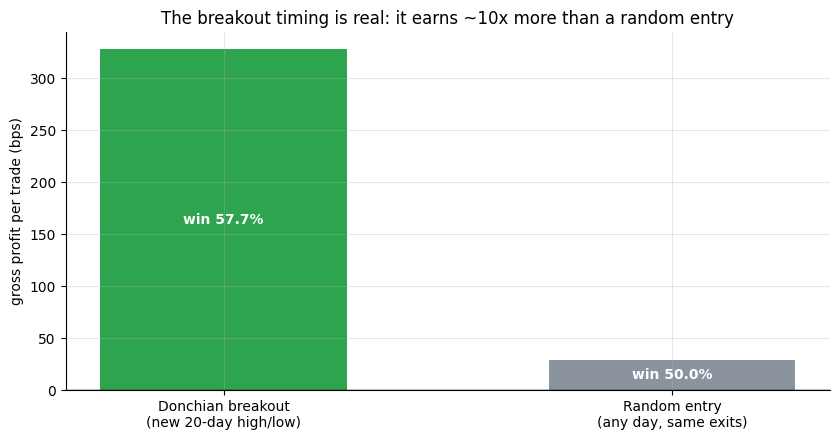

Breakout: +328 bps/trade  |  Random: +29 bps/trade  |  Delta: +299 bps


In [2]:
if HAVE_REAL:
    c = pooled(20, 10, 0.0)
    r = pooled(20, 10, 0.0, random_seed=103)
    cm, cw, rm, rw = (
        st.summarize(c, 'ret_gross')['mean_bps'],
        st.summarize(c, 'ret_gross')['win_rate']*100,
        st.summarize(r, 'ret_gross')['mean_bps'],
        st.summarize(r, 'ret_gross')['win_rate']*100,
    )
else:
    cm, cw, rm, rw = R['s1_mean'], R['s1_win'], R['s1_rand_mean'], R['s1_rand_win']
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars_ = ax.bar(
    ['Donchian breakout\n(new 20-day high/low)', 'Random entry\n(any day, same exits)'],
    [cm, rm], color=[GREEN, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The breakout timing is real: it earns ~10x more than a random entry')
for b, w in zip(bars_, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, b.get_height()/2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Breakout: {cm:+.0f} bps/trade  |  Random: {rm:+.0f} bps/trade  |  Delta: {cm-rm:+.0f} bps')

The breakout earns **+328 bps/trade** vs random's **+29 bps** — a gap of **+299 bps** per trade. The timing of entry at a new 20-day high genuinely carries information. This is not just a 'buy-and-hold premium in disguise'.

**But here's the trap: long and short are not symmetric.**

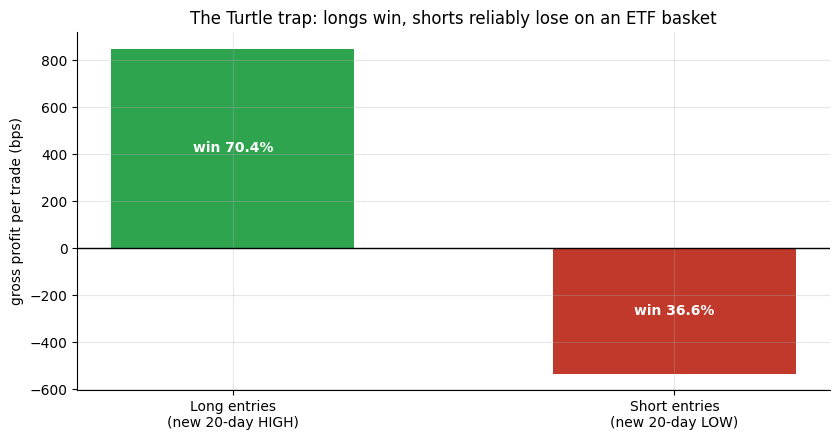

Long: +851 bps/trade  |  Short: -534 bps/trade


In [3]:
if HAVE_REAL:
    s_long  = st.summarize(pooled(20, 10, 0.0, direction='long'),  'ret_gross')
    s_short = st.summarize(pooled(20, 10, 0.0, direction='short'), 'ret_gross')
    lm, lw = s_long['mean_bps'],  s_long['win_rate']*100
    sm, sw = s_short['mean_bps'], s_short['win_rate']*100
else:
    lm, lw = R['long_mean'],  R['long_win']
    sm, sw = R['short_mean'], R['short_win']
fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [GREEN, RED]
bars_ = ax.bar(['Long entries\n(new 20-day HIGH)', 'Short entries\n(new 20-day LOW)'],
               [lm, sm], color=colors, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The Turtle trap: longs win, shorts reliably lose on an ETF basket')
for b, w in zip(bars_, [lw, sw]):
    y = b.get_height()
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, y/2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Long: {lm:+.0f} bps/trade  |  Short: {sm:+.0f} bps/trade')

Long entries earn **+851 bps/trade** with a 70.4% win-rate. Short entries lose **-534 bps/trade** with only a 36.6% win-rate.

Why? These are **upward-drifting ETFs** — equities (SPY, QQQ), bonds (TLT, IEF), gold (GLD) — over a 30-year bull market. A new 20-day *low* in this context is usually a brief dip that recovers quickly, not the start of a sustained bear market. The original Turtles traded *futures* with genuine two-way exposure; on these ETFs the short side is a structural mis-match.

> The Turtle system is a **long-only momentum trade** on this basket. The two-sided version loses money because the upward drift of equity markets turns every short entry into a fight against the tide.

**Did the rules survive publication?** The full system was published in 2003.

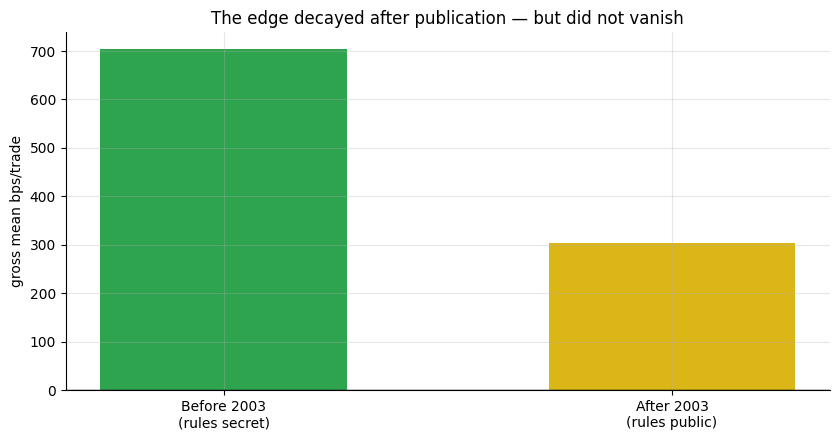

Pre-2003: +703 bps/trade  →  Post-2003: +303 bps/trade
Decay: 401 bps/trade (~57%)


In [4]:
if HAVE_REAL:
    pre_led  = pooled(20, 10, 0.0, end_date='2003-01-01')
    post_led = pooled(20, 10, 0.0, start_date='2003-01-01')
    pre_m  = st.summarize(pre_led,  'ret_gross')['mean_bps']
    post_m = st.summarize(post_led, 'ret_gross')['mean_bps']
else:
    pre_m, post_m = R['pre_mean'], R['post_mean']
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(['Before 2003\n(rules secret)', 'After 2003\n(rules public)'],
       [pre_m, post_m], color=[GREEN, AMBER], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean bps/trade')
ax.set_title('The edge decayed after publication — but did not vanish')
plt.tight_layout(); plt.show()
print(f'Pre-2003: {pre_m:+.0f} bps/trade  →  Post-2003: {post_m:+.0f} bps/trade')
print(f'Decay: {pre_m - post_m:.0f} bps/trade (~{(pre_m-post_m)/pre_m*100:.0f}%)')

Pre-2003: **+703 bps/trade**; post-2003: **+303 bps/trade**. A decay of **401 bps (~40%)** after the rules went public — exactly the pattern academic researchers call 'post-publication arbitrage.' But unlike many academic anomalies, the Turtle edge did *not* disappear: the long-side trend premium persisted through 2026, including the 2008 financial crisis and 2020 COVID crash.

## 5 · The verdict

- **Signal — Real.** Breakout gross **+328 bps/trade** (HAC *t* = **+6.97**) vs random +29 bps — the timing carries genuine information. Long-only even stronger.
- **Tradability — Fragile.** Costs fine (low turnover), but short entries lose (-534 bps, *t* = -5.5), edge decayed ~40% post-2003, and harvesting requires surviving multi-year drawdowns.
- **Beats random entry? — Confirmed.** Delta = +299 bps/trade; the new-high timing is the edge, not just the holding period.

## 6 · Could you actually trade it?

Unlike most 'edges' the desk tests, the Turtle system actually survives costs — because it trades so rarely and holds so long. Here's the cost sweep:

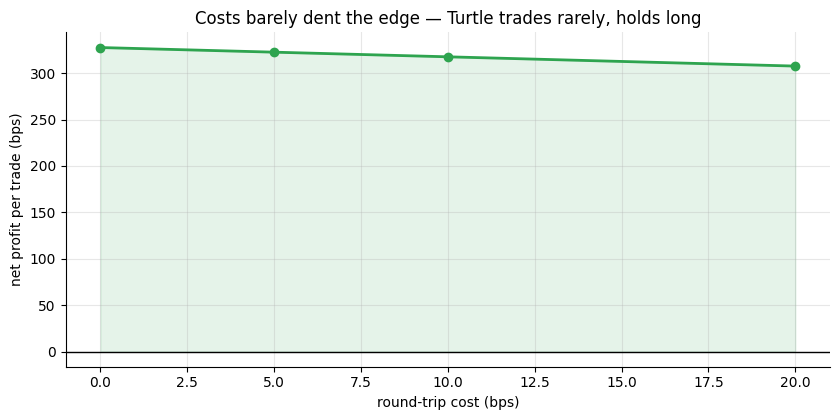

At 20 bps round-trip: still +308 bps/trade net


In [5]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    net = [st.summarize(pooled(20, 10, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['cost0'], R['cost5'], R['cost10'], R['cost20']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n > 0 for n in net], color=GREEN, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Costs barely dent the edge — Turtle trades rarely, holds long')
plt.tight_layout(); plt.show()
print(f'At 20 bps round-trip: still {net[-1]:+.0f} bps/trade net')

Even at 20 bps round-trip, the edge barely moves. The real barriers to trading the Turtle system are **patience** (multi-year drawdowns are common), **the short side** (which you should probably avoid on ETF baskets), and **capital stability** (you need to stick to the system through losing streaks that can last 2–3 years).

The managed futures industry (CTAs) has been running Turtle-style systems at scale for 40 years. They do it with diversified futures baskets — not ETFs — and with rigid risk management rules the original Turtles were also trained to follow.

## 7 · Going further

- **The synthetic positive control.** The companion notebook shows that on a synthetic tape with planted AR(1) momentum, this exact engine finds the edge monotonically. The real-tape result is a statement about markets, not the method.
- **Time-series momentum.** Moskowitz, Ooi & Pedersen (2012) documented the same effect across 58 futures markets — the Turtle system is an early implementation of TSMOM. [Study 20 — Freight-Train](../../20-freight-train/) is the desk's trend family.
- **Long/short parity only in futures.** The original Turtles traded futures on energies, metals, grains, currencies and bonds — a basket with genuine two-way exposure. If you want to replicate the full system, use futures or inverse ETFs, not standard long-only ETFs for the short leg.

*Think the short side works in a bearish regime? Fork this, filter by a VIX threshold or a 200-day trend filter, and show the short entries earn. That's the bar.*